# Calibration of refractive index

Here, we use height data from Tomocube and Holomonitor to calibrate the refractive index distribution for Tomocube. 
The calibration relies on the assumption that both microscopes measure the same quantity, 
$\int dz \,\Delta \bar{n}(\rho)$, under different assumptions.

- Holomonitor assumes a constant $\bar{n}(\rho) = 1.38-1.34=0.04$, such that $\int dz \,\Delta \bar{n}(\rho) = 0.04\,\bar{h}$
- Tomocube does not assume anything about the density dependence of the RI contrast, but the measurements are not calibrated.

In [13]:
import sys
import json
import numpy as np
import scipy as sc
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.optimize import least_squares

sys.path.append("scripts/utils/")
from file_operations import *
from SegmentedCells  import SegmentedCells
from Microscopes     import Holomonitor, Tomocube

In [14]:
def poly2(p, x):
    return p[0] + p[1] * x + p[2] * x**2

In [15]:
_2DQPI = Holomonitor()
_3DQPI = Tomocube()
alpha  = 0.19

In [16]:
data_path = "../../../../hdd_data/silja/Monolayers/"

datasets_2D = [
    "MDCK_20240301_B1-4",
    "MDCK_20240301_B2-2",
    "MDCK_20240301_B2-6",
    "MDCK_20240317_B1-1",
    "MDCK_20240319_A1-9",
    "MDCK_20240319_A1-13",
    "MDCK_20240319_A1-16",
    "MDCK_20240319_A1-18",
    "MDCK_20240319_B1-11",
    "MDCK_20240516_A2-1", 
    "MDCK_20240516_A2-7",
    "MDCK_20240516_B1-9",
    "MDCK_20240516_B1-13",
    "MDCK_20240516_B1-22"
]

datasets_3D = [
    "MDCK_20250904_B1-1",
    "MDCK_20250210_A2-1"
]

# Colormaps for plots
cmap_2D = mpl.colormaps['Blues']  (np.linspace(0.2, 0.9, len(datasets_2D)))
cmap_3D = mpl.colormaps['Greens'] (np.linspace(0.5, 0.7, len(datasets_3D)))

In [23]:
hmean_2D     = []
densities_2D = []

for dataset in datasets_2D:

    # load data
    config = json.load(open(f"configs/{dataset}.json"))
    stack  = load_stack(f"{data_path}height_fields/raw/{dataset}/", config, data_type="cells")
    cells  = SegmentedCells(f"{data_path}cell_features/calibrated/{dataset}_cells.p")

    # Compute mean height of monolayer
    hmean_tmp = np.array([np.mean(frame[frame > 0]) for frame in stack])

    # Correct height fields without reference point in data
    hmean_tmp = hmean_tmp + config["calibration"]["hshift"]

    # hmean_2D.append( hmean_tmp )
    hmean_2D.append( np.mean(cells.h, axis=1))
    densities_2D.append(cells.density)


State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240301_B1-4_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240301_B2-2_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240301_B2-6_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240317_B1-1_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-9_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-13_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-16_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_A1-18_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20240319_B1-11_cells.p.
State loaded fr

In [24]:
hmean_3D     = []
nmean_3D     = []
densities_3D = []

for dataset in datasets_3D:

    # load data
    config  = json.load(open(f"configs/{dataset}.json"))
    hstack  = load_stack(f"{data_path}height_fields/raw/{dataset}/", config, param="height", data_type="cells")
    nstack  = load_stack(f"{data_path}ri_fields/raw/{dataset}/",     config, param="ri",     data_type="cells")
    cells   = SegmentedCells(f"{data_path}cell_features/calibrated/{dataset}_cells.p")

    # Compute mean height of monolayer
    hmean_tmp = np.array([np.mean(h[h > 0]) for h in hstack])
    nmean_tmp = np.array([np.mean(n[h > 0]) for n,h in zip(nstack, hstack)])

    # hmean_3D.append( hmean_tmp )
    hmean_3D.append( np.mean(cells.h, axis=1) )
    nmean_3D.append( nmean_tmp + config["calibration"]["nshift"])
    densities_3D.append(cells.density)


State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20250904_B1-1_cells.p.
State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/calibrated/MDCK_20250210_A2-1_cells.p.


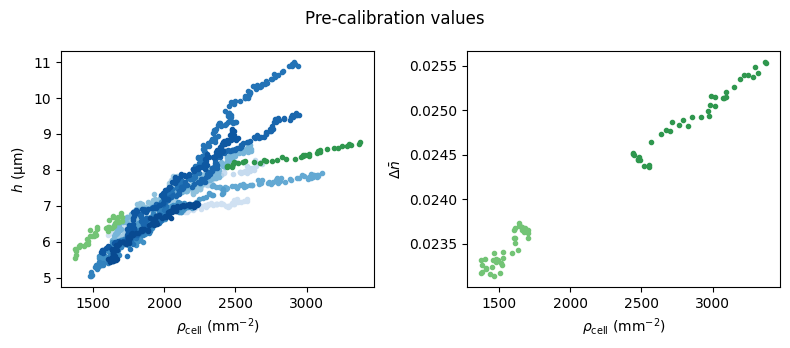

In [25]:
fig, ax = plt.subplots(1,2, figsize=(8,3.5))
fig.suptitle("Pre-calibration values")
ax[0].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$h$ (µm)");
ax[1].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$\Delta \bar{n}$");

for h, rho, c in zip(hmean_2D,
                     densities_2D,
                     cmap_2D):
    ax[0].plot(rho, h, '.', c=c)


for h, n, rho, c in zip(hmean_3D,
                        nmean_3D,
                        densities_3D,
                        cmap_3D):
    ax[0].plot(rho, h, '.', c=c)
    ax[1].plot(rho, n - _3DQPI.n0, '.', c=c)

fig.tight_layout()
# fig.savefig("results/tmp/precalibration.png", dpi=300)

## Bin by density

In [8]:
density_bins = np.arange(1300, 3400, 100)
density      = (density_bins[1:] + density_bins[:-1]) / 2

In [9]:
hs_arr      = []  # mean h
ns_arr      = []  # mean n

hs_std_arr  = []  # std h
ns_std_arr  = []  # std n

# Bin data by density
i = 0
for rhos, hs in zip([densities_2D, densities_3D],
                    [hmean_2D,     hmean_3D]):
    
    h_arr     = []  # mean per bin
    h_std_arr = []  # std per bin

    n_arr     = []  # mean per bin
    n_std_arr = []  # std per bin

    j = 0
    for rho, h in zip(rhos, hs):
        bin_idx = np.digitize(rho, density_bins) - 1

        # Only keep x values that fall inside bins
        mask = (bin_idx >= 0) & (bin_idx < len(density_bins) - 1)
        bin_idx = bin_idx[mask]
        h_tmp   = h[mask] 

        # Aggregate y per bin, e.g. sum and mean
        count     = np.bincount(bin_idx, minlength=len(density_bins)-1)

        # --- h statistics ---
        # sum(h) and sum(h^2) per bin
        h_sum   = np.bincount(bin_idx, weights=h_tmp,
                              minlength=len(density_bins) - 1)
        h_sumsq = np.bincount(bin_idx, weights=h_tmp**2,
                              minlength=len(density_bins) - 1)

        h_mean = np.zeros_like(h_sum, dtype=float)
        h_var  = np.zeros_like(h_sum, dtype=float)

        valid = count > 0
        h_mean[valid] = h_sum[valid] / count[valid]
        h_var[valid]  = h_sumsq[valid] / count[valid] - h_mean[valid]**2
        h_var[h_var < 0] = 0.0  # guard against tiny negative numbers
        h_std = np.sqrt(h_var)

        h_arr.append(np.ma.array(h_mean, mask=count == 0))
        h_std_arr.append(np.ma.array(h_std,  mask=count == 0))
                # --- n statistics (only for i == 1, i.e. 3D case) ---

        # --- n statistics (only for i == 1, i.e. 3D case) ---
        if i == 1:
            n_tmp   = nmean_3D[j][mask] - _3DQPI.n0

            n_sum   = np.bincount(bin_idx, weights=n_tmp,
                                  minlength=len(density_bins) - 1)
            n_sumsq = np.bincount(bin_idx, weights=n_tmp**2,
                                  minlength=len(density_bins) - 1)

            n_mean = np.zeros_like(n_sum, dtype=float)
            n_var  = np.zeros_like(n_sum, dtype=float)

            n_mean[valid] = n_sum[valid] / count[valid]
            n_var[valid]  = n_sumsq[valid] / count[valid] - n_mean[valid]**2
            n_var[n_var < 0] = 0.0
            n_std = np.sqrt(n_var)

            n_arr.append(np.ma.array(n_mean, mask=count == 0))
            n_std_arr.append(np.ma.array(n_std,  mask=count == 0))

        j += 1

    hs_arr.append(h_arr)
    ns_arr.append(n_arr)

    hs_std_arr.append(h_std_arr)
    ns_std_arr.append(n_std_arr)

    i += 1

# Means
hbinned_2D  = hs_arr[0]
hbinned_3D  = hs_arr[1]
nbinned_3D  = ns_arr[1]

# Standard deviations
hbinned_std_2D = hs_std_arr[0]
hbinned_std_3D = hs_std_arr[1]
nbinned_std_3D = ns_std_arr[1]


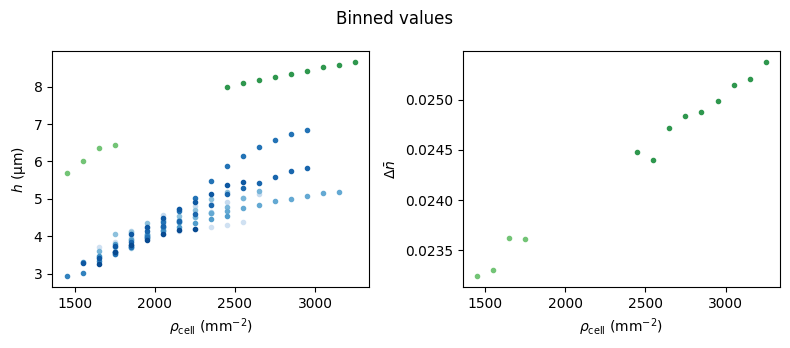

In [10]:
fig, ax = plt.subplots(1,2, figsize=(8,3.5))
fig.suptitle("Binned values")
ax[0].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$h$ (µm)");
ax[1].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$\Delta \bar{n}$");

for h, c in zip(hbinned_2D,
                cmap_2D):
    ax[0].plot(density,        h, '.', c=c)

for h, n, c in zip(hbinned_3D,
                   nbinned_3D,
                   cmap_3D):
    ax[0].plot(density, h, '.', c=c)
    ax[1].plot(density, n, '.', c=c)

fig.tight_layout()

## Fit

In [11]:
# concatenate and remove empty elements of density, mean height and std height
h2D = np.ma.concatenate(hbinned_2D)
h3D = np.ma.concatenate(hbinned_3D)
dn3D = np.ma.concatenate(nbinned_3D)

rho_2D = np.tile(density, len(hbinned_2D))[~h2D.mask]
rho_3D = np.tile(density, len(hbinned_3D))[~h3D.mask]

h2D = h2D.compressed()
h3D = h3D.compressed()
dn3D = dn3D.compressed()
# dn3D = n3D

h2D_sig = np.ma.concatenate(hbinned_std_2D).compressed()
h3D_sig = np.ma.concatenate(hbinned_std_3D).compressed()
n3D_sig = np.ma.concatenate(nbinned_std_3D).compressed()

wh2D = np.ones_like(h2D_sig)
wh3D = np.ones_like(h3D_sig)
wn3D = np.ones_like(n3D_sig)

wh2D[h2D_sig > 0] = wh2D[h2D_sig > 0] / h2D_sig[h2D_sig > 0]
wh3D[h3D_sig > 0] = wh3D[h3D_sig > 0] / h3D_sig[h3D_sig > 0]
wn3D[n3D_sig > 0] = wn3D[n3D_sig > 0] / n3D_sig[n3D_sig > 0]

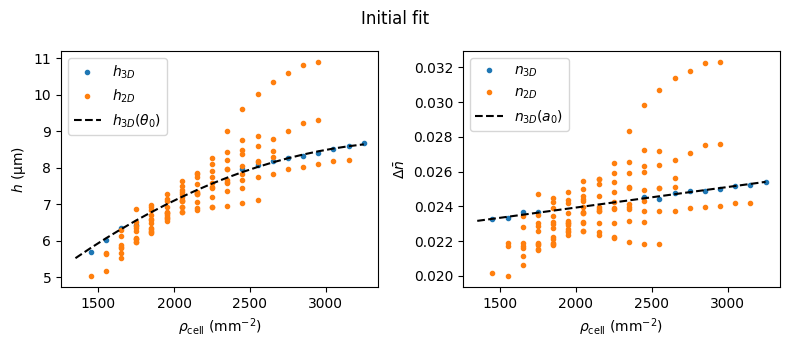

In [12]:
# Fit polynomial to 3D QPI heights
theta = np.polyfit(rho_3D, h3D,  2, w=wh3D)[::-1]
a0    = np.polyfit(rho_3D, dn3D, 2, w=wn3D)[::-1]

# Compute fit values at 2D QPI densities
h3D_at_2D  = poly2(theta, rho_2D)
dn3D_at_2D = poly2(a0, rho_2D)

# Estimate shift
dn2D = 0.04 * h2D / h3D_at_2D
n_shift  = np.polyfit(rho_2D, dn2D - dn3D_at_2D, 0)

h2D_calib0 = _2DQPI.dn0 * h2D / (dn3D_at_2D + n_shift)
dn3D = dn3D + n_shift

# dn3D = n3D_calib0 - _3DQPI.n0
a   = np.array([a0[0]+n_shift[0], a0[1], a0[2]])

fig, ax = plt.subplots(1,2, figsize=(8,3.5))
fig.suptitle("Initial fit")

ax[0].plot(rho_3D, h3D,        '.', label=r"$h_{3D}$")
ax[0].plot(rho_2D, h2D_calib0, '.', label=r"$h_{2D}$")
ax[0].plot(density, poly2(theta, density), 'k--', label=r"$h_{3D}(\theta_0)$")
ax[0].legend()

ax[1].plot(rho_3D,  dn3D, '.', label=r"$n_{3D}$")
ax[1].plot(rho_2D,  dn2D, '.', label=r"$n_{2D}$")
ax[1].plot(density, poly2(a, density), 'k--', label=r"$n_{3D}(a_0)$")
ax[1].legend()


ax[0].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$h$ (µm)");
ax[1].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$\Delta \bar{n}$");

fig.tight_layout()

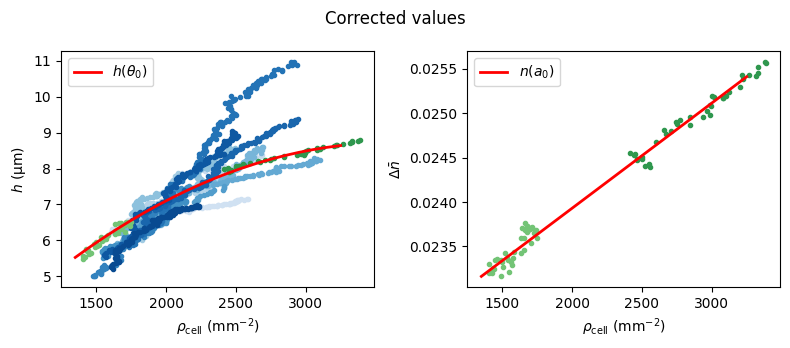

In [13]:
fig, ax = plt.subplots(1,2, figsize=(8,3.5))
fig.suptitle("Corrected values")
ax[0].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$h$ (µm)");
ax[1].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$\Delta \bar{n}$");

for rho, h, c in zip(densities_2D,
                     hmean_2D,
                     cmap_2D):
    ax[0].plot(rho, _2DQPI.dn0 * h / poly2(a, rho), '.', c=c)
    

for rho, h, n, c in zip(densities_3D,
                        hmean_3D,
                        nmean_3D,
                        cmap_3D):
    ax[0].plot(rho, h, '.', c=c)
    ax[1].plot(rho, n - _3DQPI.n0 + n_shift, '.', c=c)


# final height fit
ax[0].plot(density, poly2(theta, density), 'r-', lw=2, label=r"$h(\theta_0)$")
ax[1].plot(density, poly2(a, density),     'r-', lw=2, label=r"$n(a_0)$")

ax[0].legend()
ax[1].legend()

fig.tight_layout()
# fig.savefig("results/tmp/postcalibration.png", dpi=300)

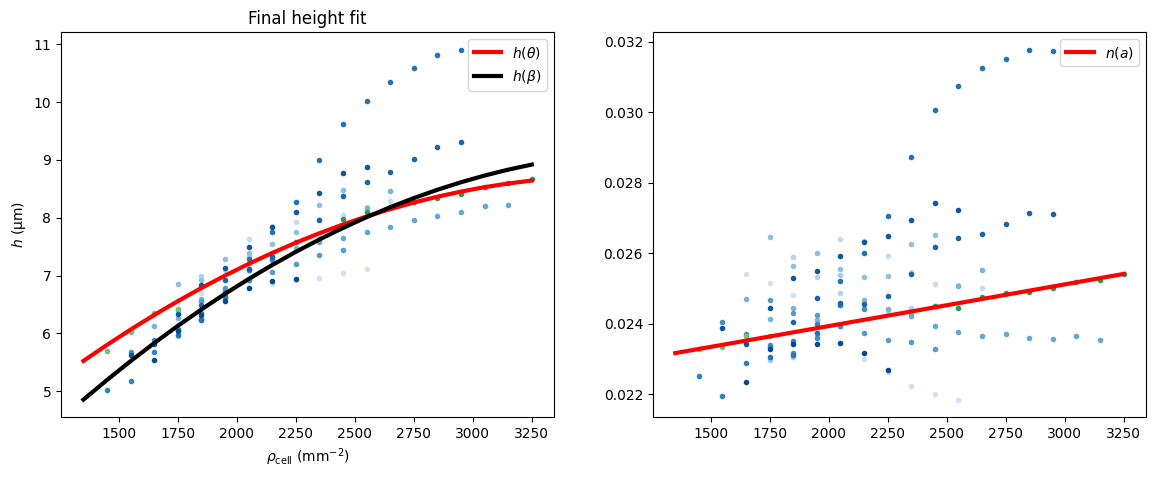

In [14]:
# final height fit
h_from_2D = _2DQPI.dn0 * h2D / poly2(a, rho_2D)

rho_combined = np.concatenate([rho_2D, rho_3D])
h_combined   = np.concatenate([h_from_2D, h3D])
w_combined   = np.concatenate([wh2D, wh3D])

# weighted polyfit
beta = np.polyfit(rho_combined, h_combined, 2, w=w_combined)[::-1]
h3D_at_2D = poly2(beta, rho_2D)

plt.figure(figsize=(14,5))
plt.subplot(121)
plt.title("Final height fit")
plt.xlabel(r"$\rho_{\text{cell}}$ (mm$^{-2}$)")
plt.ylabel(r"$h$ (µm)");

for h, c in zip(hbinned_2D,
                cmap_2D):
    plt.plot(density, _2DQPI.dn0 * h / poly2(a, density), '.', c=c)

for h, n, c in zip(hbinned_3D,
                   nbinned_3D,
                   cmap_3D):
    plt.plot(density, h, '.', c=c)
    
plt.plot(density, poly2(theta, density), 'r-', lw=3, label=r"$h(\theta)$")
plt.plot(density, poly2(beta, density),  'k-', lw=3, label=r"$h(\beta)$")
plt.legend()



plt.subplot(122)
for h, c in zip(hbinned_2D,
                cmap_2D):
    plt.plot(density, _2DQPI.dn0 * h  / poly2(beta, density), '.', c=c)

for h, n, c in zip(hbinned_3D,
                   nbinned_3D,
                   cmap_3D):
    plt.plot(density, n + n_shift, '.', c=c)

plt.plot(density, poly2(a, density), 'r-', lw=3, label=r"$n(a)$")
plt.legend()

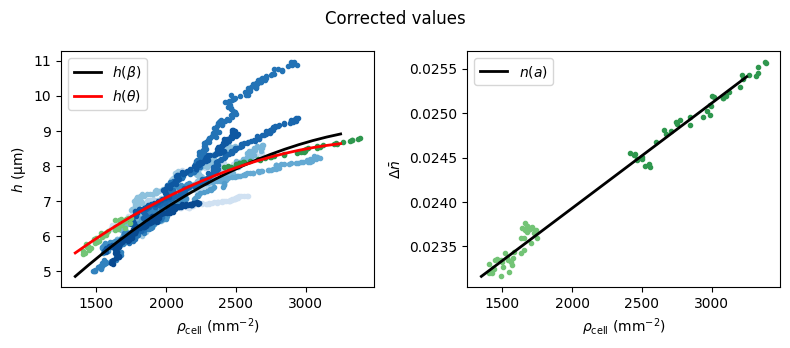

In [15]:
fig, ax = plt.subplots(1,2, figsize=(8,3.5))
fig.suptitle("Corrected values")
ax[0].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$h$ (µm)");
ax[1].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$\Delta \bar{n}$");

for rho, h, c in zip(densities_2D,
                     hmean_2D,
                     cmap_2D):
    ax[0].plot(rho, _2DQPI.dn0 * h / poly2(a, rho), '.', c=c)
    

for rho, h, n, c in zip(densities_3D,
                        hmean_3D,
                        nmean_3D,
                        cmap_3D):
    ax[0].plot(rho, h, '.', c=c)
    ax[1].plot(rho,  n + n_shift - _3DQPI.n0, '.', c=c)


# fin
ax[0].plot(density, poly2(beta,   density), '-k', lw=2, label=r"$h(\beta)$")
ax[0].plot(density, poly2(theta,  density), '-r', lw=2, label=r"$h(\theta)$")
ax[1].plot(density, poly2(a,      density), '-k', lw=2, label=r"$n(a)$")

ax[0].legend()
ax[1].legend()

fig.tight_layout()

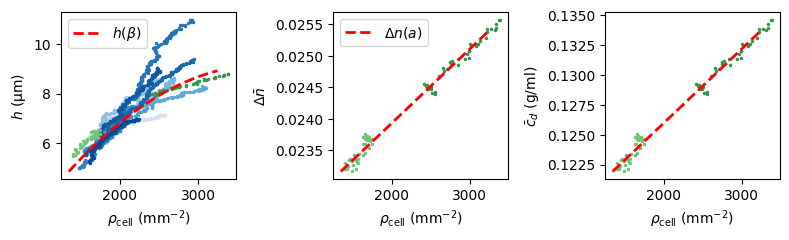

In [16]:
fig, ax = plt.subplots(1,3, figsize=(8,2.5))
ax[0].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$h$ (µm)");
ax[1].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$\Delta \bar{n}$");
ax[2].set(xlabel=r"$\rho_{\text{cell}}$ (mm$^{-2}$)", ylabel=r"$\bar{c}_d$ (g/ml)");

for rho, h, c in zip(densities_2D,
                     hmean_2D,
                     cmap_2D):
    ax[0].plot(rho, _2DQPI.dn0 * h / poly2(a, rho), '.', c=c, ms=3)
    

for rho, h, n, c in zip(densities_3D,
                        hmean_3D,
                        nmean_3D,
                        cmap_3D):
    ax[0].plot(rho, h, '.', c=c, ms=3)
    ax[1].plot(rho,  n + n_shift - _3DQPI.n0, '.', c=c, ms=3)
    ax[2].plot(rho,  (n + n_shift - _3DQPI.n0) / alpha, '.', c=c, ms=3)


# fin
ax[0].plot(density, poly2(beta,   density), '--r', lw=2, label=r"$h(\beta)$")
ax[1].plot(density, poly2(a,      density), '--r', lw=2, label=r"$\Delta n(a)$")
ax[2].plot(density, poly2(a,      density) / alpha, '--r', lw=2, label=r"$\Delta n(a)/\alpha$")

ax[0].legend()
ax[1].legend()

fig.tight_layout()
fig.savefig("figs/Elife/ri_model.svg")